In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
assert project_root.name == "digital-twin-lite", f"Root salah: {project_root}"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd

from src.config import SeparatorParams, SimConfig
from src.state_estimation import EKFConfig, run_ekf_on_log, save_ekf_result

In [2]:
df_log = pd.read_csv(project_root / "data" / "raw" / "sensor_log.csv")
df_log.head()

,t_s,qin_m3s,qout_m3s,u,L_m,Vg_m3,n_mol,P_Pa,n_in_mols,n_out_mols,dP_liq_Pa,L_true_m,P_true_Pa,L_meas_m,P_meas_Pa,L_missing,P_missing
0,0.0,0.000,0.000000,0.00,1.000000,9.000000,400.000000,118243.555556,0.0,0.000000,0.000000,1.000000,118243.555556,1.003047,118097.697316,False,False
1,0.5,0.004,0.002185,0.55,1.000302,8.999093,396.797146,117308.590686,4.0,10.405708,25257.055556,1.000302,117308.590686,0.989903,117434.658699,False,False
2,1.0,0.004,0.002144,0.55,1.000612,8.998165,393.740097,116416.810548,4.0,10.114098,24324.612785,1.000612,116416.810548,1.008116,116386.091536,False,False
3,1.5,0.004,0.002105,0.55,1.000928,8.997217,390.826148,115567.415151,4.0,9.827898,23435.411330,1.000928,115567.415151,1.010333,115372.246065,False,False
4,2.0,0.004,0.002067,0.55,1.001250,8.996251,388.052484,114759.572474,4.0,9.547327,22588.649598,1.001250,114759.572474,0.981739,114557.308736,False,False


In [3]:
params = SeparatorParams(
    A=3.0,
    V_total=12.0,
    L_max=3.0,
    V_min=0.2,
    rho_l=850.0,
    g=9.81,
    Patm=101_325.0,
    P_out=101_325.0,
    Cv_l=2.5e-5,          # ganti dengan hasil kalibrasi jika sudah
    R=8.314,
    T=320.0,
    kg_n_sqrt=0.08,       # ganti dengan hasil kalibrasi jika sudah
    n_out_max=30.0
)

sim = SimConfig(dt=0.5, t_end=600.0)

ekf_cfg = EKFConfig(
    q_L=1e-6,
    q_n=1e-2,
    r_L=(0.01**2),
    r_P=(300.0**2),
)

In [5]:
#Menjalankan Extended Kalman Filter
df_est = run_ekf_on_log(df_log=df_log, params=params, sim=sim, ekf_cfg=ekf_cfg)
df_est.head()

,t_s,qin_m3s,qout_m3s,u,L_m,Vg_m3,n_mol,P_Pa,n_in_mols,n_out_mols,...,P_true_Pa,L_meas_m,P_meas_Pa,L_missing,P_missing,L_est_m,P_est_Pa,n_est_mol,res_L,res_P
0,0.0,0.000,0.000000,0.00,1.000000,9.000000,400.000000,118243.555556,0.0,0.000000,...,118243.555556,1.003047,118097.697316,False,False,1.003047,118097.697316,399.100795,0.000000,0.000000
1,0.5,0.004,0.002185,0.55,1.000302,8.999093,396.797146,117308.590686,4.0,10.405708,...,117308.590686,0.989903,117434.658699,False,False,0.996731,117296.637358,397.229037,-0.013448,266.206183
2,1.0,0.004,0.002144,0.55,1.000612,8.998165,393.740097,116416.810548,4.0,10.114098,...,116416.810548,1.008116,116386.091536,False,False,1.000743,116401.424676,393.670882,0.011075,-20.395355
3,1.5,0.004,0.002105,0.55,1.000928,8.997217,390.826148,115567.415151,4.0,9.827898,...,115567.415151,1.010333,115372.246065,False,False,1.003388,115511.748142,390.317469,0.009275,-180.489556
4,2.0,0.004,0.002067,0.55,1.001250,8.996251,388.052484,114759.572474,4.0,9.547327,...,114759.572474,0.981739,114557.308736,False,False,0.999041,114669.752383,388.034419,-0.021971,-148.701610


In [6]:
#Menyimpan hasil ekf
out_path = save_ekf_result(project_root, df_est, filename="data/processed/ekf_result.csv")
out_path

WindowsPath('C:/Users/LENOVO/digital-twin-lite/data/processed/ekf_result.csv')

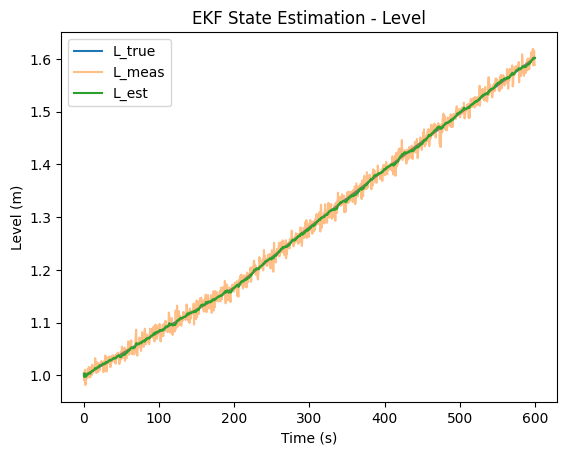

In [7]:
#Plot level untuk estimation vs measured
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_est["t_s"], df_est["L_true_m"], label="L_true")
plt.plot(df_est["t_s"], df_est["L_meas_m"], label="L_meas", alpha=0.5)
plt.plot(df_est["t_s"], df_est["L_est_m"], label="L_est")
plt.xlabel("Time (s)")
plt.ylabel("Level (m)")
plt.title("EKF State Estimation - Level")
plt.legend()
plt.show()

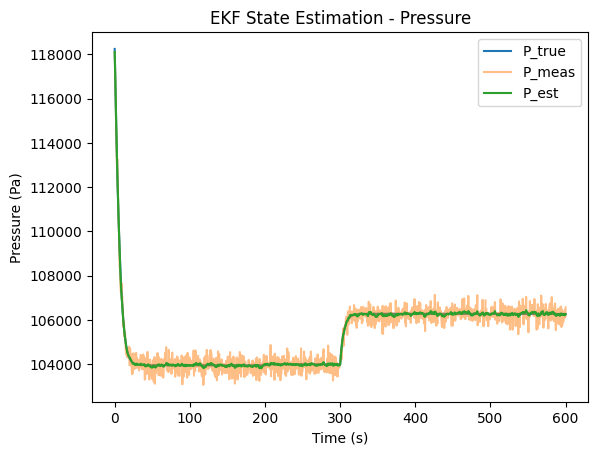

In [8]:
#Plot untuk pressure
plt.figure()
plt.plot(df_est["t_s"], df_est["P_true_Pa"], label="P_true")
plt.plot(df_est["t_s"], df_est["P_meas_Pa"], label="P_meas", alpha=0.5)
plt.plot(df_est["t_s"], df_est["P_est_Pa"], label="P_est")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.title("EKF State Estimation - Pressure")
plt.legend()
plt.show()

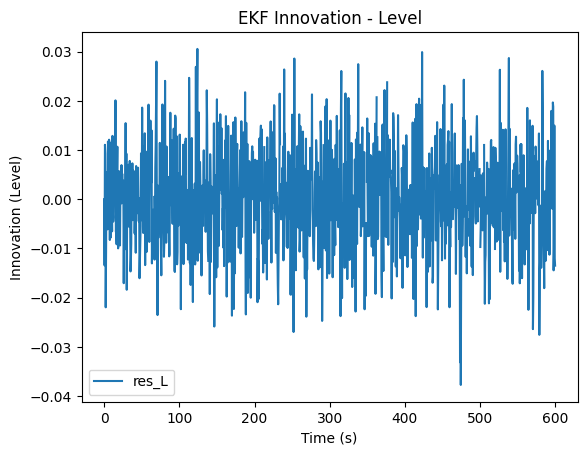

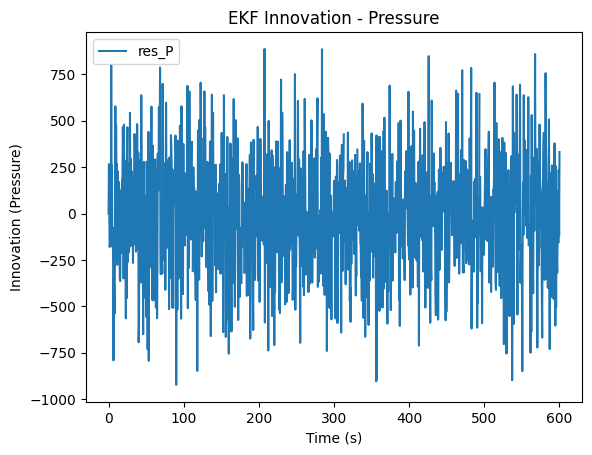

In [9]:
#Plot residual
plt.figure()
plt.plot(df_est["t_s"], df_est["res_L"], label="res_L")
plt.xlabel("Time (s)")
plt.ylabel("Innovation (Level)")
plt.title("EKF Innovation - Level")
plt.legend()
plt.show()

plt.figure()
plt.plot(df_est["t_s"], df_est["res_P"], label="res_P")
plt.xlabel("Time (s)")
plt.ylabel("Innovation (Pressure)")
plt.title("EKF Innovation - Pressure")
plt.legend()
plt.show()